# Krishna Menon
# B.Tech I045

### https://realpython.com/generative-adversarial-networks/

In [1]:
import torch
from torch import nn

import math
import matplotlib.pyplot as plt

In [2]:
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

Torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
torch.manual_seed(111)

In [4]:
train_data_length = 1024
train_data = torch.zeros((train_data_length, 2))
train_data[:, 0] = 2 * math.pi * torch.rand(train_data_length)
train_data[:, 1] = torch.sin(train_data[:, 0])
train_labels = torch.zeros(train_data_length)
train_set = [
    (train_data[i], train_labels[i]) for i in range(train_data_length)
]

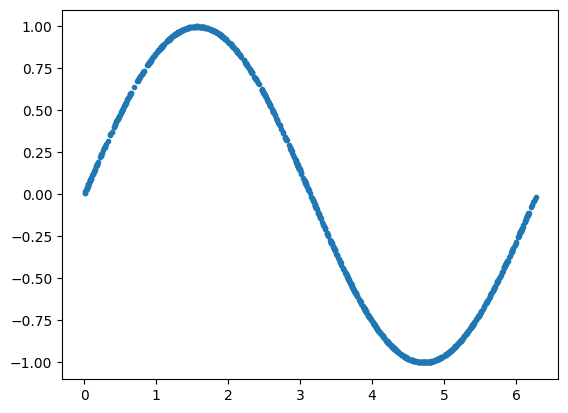

In [5]:
plt.plot(train_data[:, 0], train_data[:, 1], ".")

In [6]:
batch_size = 32
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size, shuffle=True
)

#### Defining Discriminator

In [7]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        output = self.model(x)
        return output

In [8]:
discriminator = Discriminator()

#### Defining Generator

In [9]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
        )

    def forward(self, x):
        output = self.model(x)
        return output

generator = Generator()

#### Parameters

In [10]:
lr = 0.001
num_epochs = 300
k = 1  # Discriminator updates per generator update
loss_function = nn.BCELoss()

In [11]:
optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

In [12]:
for epoch in range(num_epochs):
    for n, (real_samples, _) in enumerate(train_loader):
        # Labels for discriminator and generator targets
        real_samples_labels = torch.ones((batch_size, 1))
        generated_samples_labels = torch.zeros((batch_size, 1))

        # Train discriminator k times
        for _ in range(k):
            latent_space_samples = torch.randn((batch_size, 2))
            generated_samples = generator(latent_space_samples)
            all_samples = torch.cat((real_samples, generated_samples.detach()))
            all_samples_labels = torch.cat(
                (real_samples_labels, generated_samples_labels)
            )

            discriminator.zero_grad()
            output_discriminator = discriminator(all_samples)
            loss_discriminator = loss_function(
                output_discriminator, all_samples_labels)
            loss_discriminator.backward()
            optimizer_discriminator.step()

        # Train generator once
        latent_space_samples = torch.randn((batch_size, 2))
        generator.zero_grad()
        generated_samples = generator(latent_space_samples)
        output_discriminator_generated = discriminator(generated_samples)
        loss_generator = loss_function(
            output_discriminator_generated, real_samples_labels
        )
        loss_generator.backward()
        optimizer_generator.step()

        # Show loss
        if epoch % 10 == 0 and n == batch_size - 1:
            print(f"Epoch: {epoch} | k={k} | Loss D.: {loss_discriminator}")
            print(f"Epoch: {epoch} | k={k} | Loss G.: {loss_generator}")

Epoch: 0 | k=1 | Loss D.: 0.19106777012348175
Epoch: 0 | k=1 | Loss G.: 1.888679027557373
Epoch: 10 | k=1 | Loss D.: 0.6593940854072571
Epoch: 10 | k=1 | Loss G.: 0.9345511198043823
Epoch: 20 | k=1 | Loss D.: 0.6652078628540039
Epoch: 20 | k=1 | Loss G.: 0.9237955808639526
Epoch: 30 | k=1 | Loss D.: 0.641313910484314
Epoch: 30 | k=1 | Loss G.: 1.2015199661254883
Epoch: 40 | k=1 | Loss D.: 0.641319751739502
Epoch: 40 | k=1 | Loss G.: 0.888908863067627
Epoch: 50 | k=1 | Loss D.: 0.6150982975959778
Epoch: 50 | k=1 | Loss G.: 0.7767004370689392
Epoch: 60 | k=1 | Loss D.: 0.6709685325622559
Epoch: 60 | k=1 | Loss G.: 0.960426390171051
Epoch: 70 | k=1 | Loss D.: 0.7082744240760803
Epoch: 70 | k=1 | Loss G.: 0.6963481903076172
Epoch: 80 | k=1 | Loss D.: 0.6969344019889832
Epoch: 80 | k=1 | Loss G.: 0.7154377102851868
Epoch: 90 | k=1 | Loss D.: 0.6964524984359741
Epoch: 90 | k=1 | Loss G.: 0.6930248737335205
Epoch: 100 | k=1 | Loss D.: 0.6739951968193054
Epoch: 100 | k=1 | Loss G.: 0.682832241

In [13]:
latent_space_samples = torch.randn(100, 2)
generated_samples = generator(latent_space_samples)

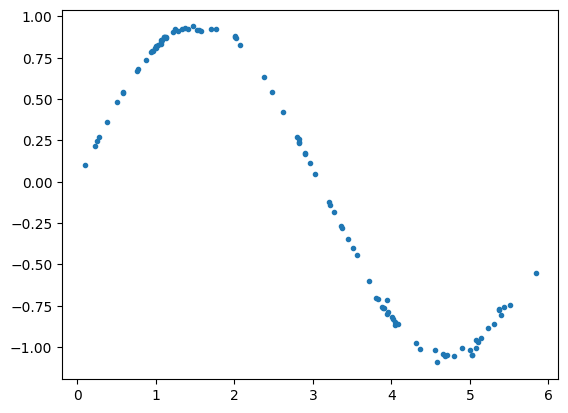

In [14]:
generated_samples = generated_samples.detach()
plt.plot(generated_samples[:, 0], generated_samples[:, 1], ".")

### Using Fashion-MNIST Dataset

In [15]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 1. Define image transformations (e.g., convert to Tensor and normalize)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 2. Download and load the datasets
train_data = datasets.FashionMNIST(
    root='data', 
    train=True, 
    download=True, 
    transform=transform
)

test_data = datasets.FashionMNIST(
    root='data', 
    train=False, 
    download=True, 
    transform=transform
)

# 3. Create DataLoaders for batch processing
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 207kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.75MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 29.0MB/s]


In [16]:
for i, (images, labels) in enumerate(train_loader):
    print(f"Batch {i+1}:")
    print(f"  Images shape: {images.shape}")
    print(f"  Labels shape: {labels.shape}")
    break  # Remove this line to iterate through the entire dataset

Batch 1:
  Images shape: torch.Size([64, 1, 28, 28])
  Labels shape: torch.Size([64])


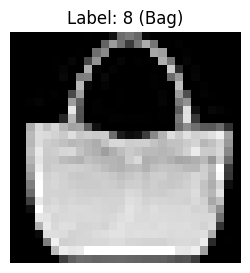

In [17]:
sample_idx = 100
image, label = train_data[sample_idx]

# Unnormalize from [-1, 1] to [0, 1] for display
image_to_show = image * 0.5 + 0.5

plt.figure(figsize=(3, 3))
plt.imshow(image_to_show.squeeze(), cmap="gray")
plt.title(f"Label: {label} ({train_data.classes[label]})")
plt.axis("off")
plt.show()

#### Fashion-MNIST GAN Models

In [18]:
# Discriminator for Fashion-MNIST (28x28 = 784 input)
class FashionDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x)

# Generator for Fashion-MNIST (latent_dim -> 784 output)
class FashionGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh(),  # Output range [-1, 1] to match normalized data
        )

    def forward(self, x):
        return self.model(x)

# Initialize models for Fashion-MNIST
latent_dim = 100
discriminator = FashionDiscriminator()
generator = FashionGenerator(latent_dim)

# Training parameters
lr = 0.0002
num_epochs = 50
batch_size = 64
k = 1  # Discriminator updates per generator update
loss_function = nn.BCELoss()

# Optimizers
optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

In [19]:
for epoch in range(num_epochs):
    for n, (real_samples, _) in enumerate(train_loader):
        current_batch_size = real_samples.size(0)

        # Flatten images for MLP-based discriminator/generator
        real_samples = real_samples.view(current_batch_size, -1)

        # Labels
        real_samples_labels = torch.ones((current_batch_size, 1))
        generated_samples_labels = torch.zeros((current_batch_size, 1))

        # ---------------------
        # Train Discriminator
        # ---------------------
        for _ in range(k):
            latent_space_samples = torch.randn((current_batch_size, latent_dim))
            generated_samples = generator(latent_space_samples)
            if generated_samples.dim() > 2:
                generated_samples = generated_samples.view(current_batch_size, -1)

            all_samples = torch.cat((real_samples, generated_samples.detach()), dim=0)
            all_samples_labels = torch.cat(
                (real_samples_labels, generated_samples_labels), dim=0
            )

            discriminator.zero_grad()
            output_discriminator = discriminator(all_samples)
            loss_discriminator = loss_function(output_discriminator, all_samples_labels)
            loss_discriminator.backward()
            optimizer_discriminator.step()

        # -----------------
        # Train Generator
        # -----------------
        latent_space_samples = torch.randn((current_batch_size, latent_dim))

        generator.zero_grad()
        generated_samples = generator(latent_space_samples)
        if generated_samples.dim() > 2:
            generated_samples = generated_samples.view(current_batch_size, -1)

        output_discriminator_generated = discriminator(generated_samples)
        loss_generator = loss_function(
            output_discriminator_generated, real_samples_labels)
        loss_generator.backward()
        optimizer_generator.step()

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | k={k} | Loss D.: {loss_discriminator.item():.4f}")
        print(f"Epoch: {epoch} | k={k} | Loss G.: {loss_generator.item():.4f}")

from pathlib import Path
import torch

checkpoint = {
    "epoch": epoch + 1,
    "generator_state_dict": generator.state_dict(),
    "discriminator_state_dict": discriminator.state_dict(),
    "optimizer_generator_state_dict": optimizer_generator.state_dict(),
    "optimizer_discriminator_state_dict": optimizer_discriminator.state_dict(),
    "latent_dim": latent_dim,
    "lr": lr,
}

# Prefer Google Drive path in Colab for persistence
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive', force_remount=False)
    save_dir = Path('/content/drive/MyDrive/ATML')
except Exception:
    save_dir = Path.cwd()

save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / 'fashion_mnist_gan_checkpoint.pth'

torch.save(checkpoint, save_path)

print(f"Model checkpoint saved to: {save_path}")
print(f"Absolute path: {save_path.resolve()}")
print(f"Exists: {save_path.exists()}")



Epoch: 0 | k=1 | Loss D.: 0.0679
Epoch: 0 | k=1 | Loss G.: 5.1872


KeyboardInterrupt: 

In [20]:
save_path = "fashion_mnist_gan_checkpoint.pth"

torch.save(
    {
        "epoch": epoch+1,
        "generator_state_dict": generator.state_dict(),
        "discriminator_state_dict": discriminator.state_dict(),
        "optimizer_generator_state_dict": optimizer_generator.state_dict(),
        "optimizer_discriminator_state_dict": optimizer_discriminator.state_dict(),
        "latent_dim": latent_dim,
        "lr": lr,
    },
    save_path,
)

print(f"Model checkpoint saved to: {save_path}")

Model checkpoint saved to: fashion_mnist_gan_checkpoint.pth


In [36]:
from pathlib import Path
import torch

checkpoint = {
    "epoch": epoch + 1,
    "generator_state_dict": generator.state_dict(),
    "discriminator_state_dict": discriminator.state_dict(),
    "optimizer_generator_state_dict": optimizer_generator.state_dict(),
    "optimizer_discriminator_state_dict": optimizer_discriminator.state_dict(),
    "latent_dim": latent_dim,
    "lr": lr,
}

# Prefer Google Drive path in Colab for persistence
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive', force_remount=False)
    save_dir = Path('/content/drive/MyDrive/ATML')
except Exception:
    save_dir = Path.cwd()

save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / 'fashion_mnist_gan_checkpoint.pth'

torch.save(checkpoint, save_path)

print(f"Model checkpoint saved to: {save_path}")
print(f"Absolute path: {save_path.resolve()}")
print(f"Exists: {save_path.exists()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model checkpoint saved to: /content/drive/MyDrive/ATML/fashion_mnist_gan_checkpoint.pth
Absolute path: /content/drive/MyDrive/ATML/fashion_mnist_gan_checkpoint.pth
Exists: True


In [25]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Using checkpoint: /content/drive/MyDrive/ATML/fashion_mnist_gan_checkpoint.pth


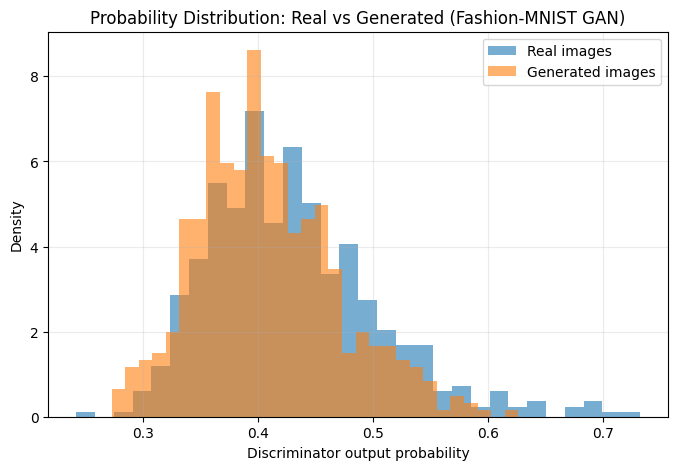

In [26]:
from pathlib import Path
import torch
from torch import nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# ---------- Model classes (self-contained) ----------
class FashionDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x)


class FashionGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.model(x)


# ---------- Find saved checkpoint ----------
candidate_paths = [
    # Path('/content/fashion_mnist_gan_checkpoint.pth'),
    Path('/content/drive/MyDrive/ATML/fashion_mnist_gan_checkpoint.pth'),
    Path('fashion_mnist_gan_checkpoint_v1.pth'),
]

ckpt_path = None
for p in candidate_paths:
    if p.exists():
        ckpt_path = p
        break

if ckpt_path is None:
    raise FileNotFoundError('Checkpoint not found in expected locations.')

print('Using checkpoint:', ckpt_path)

# ---------- Load checkpoint ----------
device = torch.device('cpu')
checkpoint = torch.load(ckpt_path, map_location=device)
latent_dim_ckpt = checkpoint.get('latent_dim', 100)

generator = FashionGenerator(latent_dim_ckpt).to(device)
discriminator = FashionDiscriminator().to(device)

generator.load_state_dict(checkpoint['generator_state_dict'])
discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
generator.eval()
discriminator.eval()

# ---------- Preprocess real data ----------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

real_data = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=transform
)

real_loader = torch.utils.data.DataLoader(real_data, batch_size=512, shuffle=True)
real_images, _ = next(iter(real_loader))
real_images = real_images.view(real_images.size(0), -1).to(device)

# ---------- Generate fake data ----------
z = torch.randn((real_images.size(0), latent_dim_ckpt), device=device)
fake_images = generator(z)

# ---------- Plot probability distributions ----------
with torch.no_grad():
    real_probs = discriminator(real_images).squeeze().cpu().numpy()
    fake_probs = discriminator(fake_images).squeeze().cpu().numpy()

plt.figure(figsize=(8, 5))
plt.hist(real_probs, bins=30, alpha=0.6, density=True, label='Real images')
plt.hist(fake_probs, bins=30, alpha=0.6, density=True, label='Generated images')
plt.xlabel('Discriminator output probability')
plt.ylabel('Density')
plt.title('Probability Distribution: Real vs Generated (Fashion-MNIST GAN)')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

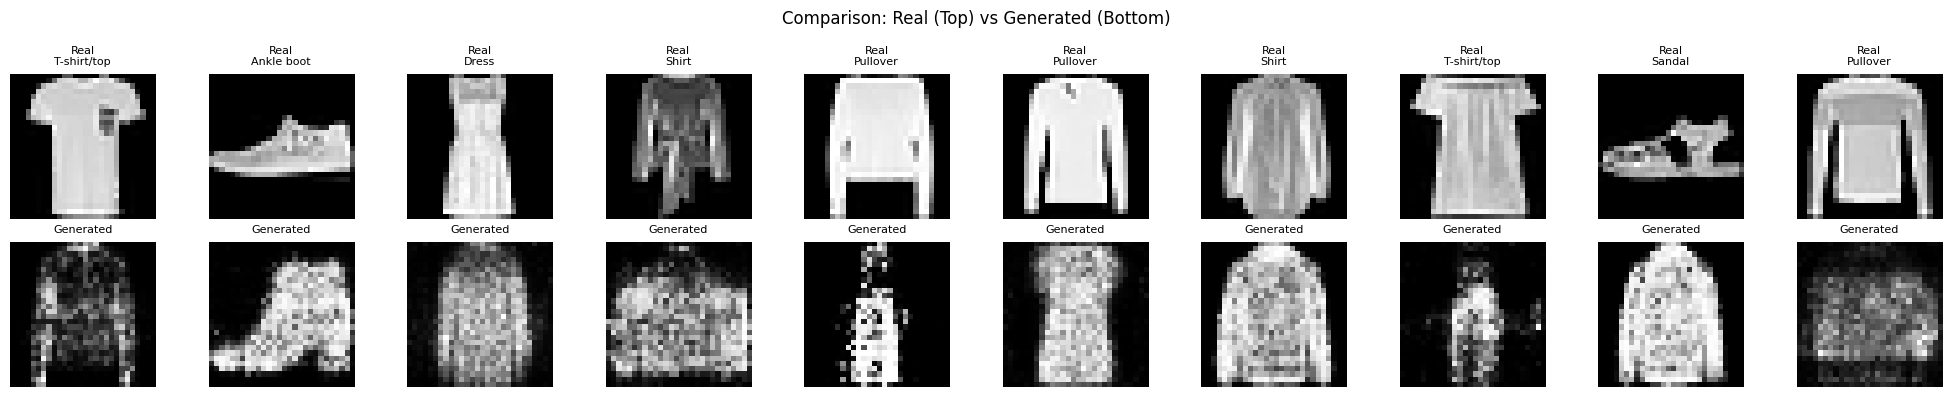

In [40]:
import torch
import matplotlib.pyplot as plt

num_samples = 10
generator.eval()

real_batch, real_labels = next(iter(real_loader))
real_batch = real_batch[:num_samples]
real_labels = real_labels[:num_samples]

with torch.no_grad():
    z = torch.randn(num_samples, latent_dim_ckpt)
    fake_batch = generator(z).view(num_samples, 1, 28, 28)

real_show = (real_batch * 0.5 + 0.5).clamp(0, 1)
fake_show = (fake_batch * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(2, num_samples, figsize=(2 * num_samples, 4))
for i in range(num_samples):
    axes[0, i].imshow(real_show[i].squeeze(), cmap='gray')
    axes[0, i].set_title(f"Real\n{real_data.classes[real_labels[i].item()]}", fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(fake_show[i].squeeze(), cmap='gray')
    axes[1, i].set_title('Generated', fontsize=8)
    axes[1, i].axis('off')

plt.suptitle('Comparison: Real (Top) vs Generated (Bottom)', fontsize=12)
plt.tight_layout()
plt.show()